In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from dataclasses import dataclass

G = 9.81 # m/s^2

In [8]:
@dataclass
class BaseState:
    state: np.ndarray
    def update_state(self, state):
        self.state = state
    def get_state(self):
        return self.state

@dataclass
class Slider(BaseState):
    size: np.ndarray # width, height 
    mass: float # kg
    nu: float # friction coefficient 
    state: np.ndarray # x, y, theta

    def __post_init__(self):
        self.A = np.prod(self.size)
    
@dataclass
class Pusher(BaseState):
    size: float
    nu: float # friction coefficient
    mass: float # kg
    control: np.ndarray # force

@dataclass
class Surface:
    nu: float # friction coefficient


In [9]:
class PlanarSystem:
    def __init__(self, slider, pusher, surface):
        self.slider = slider
        self.pusher = pusher
        self.surface = surface

        self.f_max, self.m_max, self.c = None, None, None
        self.initialize()

    def initialize(self):
        self.f_max = self.surface.nu * self.slider.mass * G
        self.m_max = self.m_max_funct()
        print("----", self.f_max, self.m_max)
        self.c = self.m_max[0] / self.f_max
        print("----", self.c)

    def m_max_funct(self):
        def n_f_integrand(p1, p2):
            return (self.surface.nu * self.slider.mass * G / (self.slider.size[0] * self.slider.size[1])) * np.sqrt(np.dot(np.array([p1, p2, 0]), np.array([p1, p2, 0])))
        n_f = integrate.dblquad(n_f_integrand, -self.slider.size[0]/2, self.slider.size[0]/2, -self.slider.size[1]/2, self.slider.size[1]/2)
        return n_f
    
    def get_state(self):
        return self.slider.get_state(), self.pusher.get_state()

    def set_state(self, state):
        self.slider.update_state(state[0:3])
        self.pusher.update_state(state[3:5])


In [150]:
class Simulator:
    def __init__(self, system, dt=0.01):
        self.system = system
        self.dt = dt

    def simulate(self, x, u):
        # Runge-Kutta 4th order method
        k1 = self.analytical_step(x, u)
        k2 = self.analytical_step(x + self.dt * k1 / 2, u)
        k3 = self.analytical_step(x + self.dt * k2 / 2, u)
        k4 = self.analytical_step(x + self.dt * k3, u)
        return x + self.dt / 6 * (k1 + 2*k2 + 2*k3 + k4)
    
    def set_state(self, x):
        self.system.set_state(x)

    def get_state(self):
        return [*self.system.slider.get_state(), *self.system.pusher.get_state()]
    
    def analytical_step(self, x, u):

        # print(x)

        p_i = x[-2:]


        theta = x[2]
        iCs = np.array([[np.cos(theta), np.sin(theta)], [-np.sin(theta), np.cos(theta)]])

        p_s = iCs @ p_i

        px_s = p_s[0]
        py_s = p_s[1]

        nu = self.system.pusher.nu
        c = self.system.c

        Q = np.zeros((2, 2))

        Q[0, 0] = c * c + px_s * px_s
        Q[0, 1] = px_s * py_s
        Q[1, 0] = px_s * py_s
        Q[1, 1] = c * c + py_s * py_s

        Q /= (c * c + px_s * px_s + py_s * py_s)


        gamma_top = (nu * c * c -  px_s * py_s + nu * px_s * px_s)/(c * c + py_s * py_s - nu * px_s * py_s)
        gamma_bottom = (-nu * c * c -  px_s * py_s - nu * px_s * px_s)/(c * c + py_s * py_s + nu * px_s * py_s)

        # print(gamma_top, gamma_bottom, u)

        vp_s = iCs @ u
        # print(vp_s)

        gamma = vp_s[1]/vp_s[0]
        # print(gamma)

        
        
        P = np.zeros((2, 2))
        if gamma > gamma_top:
            # print("sliding top")
            b = np.array([ -py_s + gamma_top * px_s, 0]) / (c * c + px_s * px_s + py_s * py_s)
            c = np.array([-gamma_top, 0])
            P[0, 0] = 1
            P[1, 0] = gamma_top
            
        elif gamma < gamma_bottom:
            # print("sliding bottom")
            b = np.array([ -py_s + gamma_bottom * px_s, 0]) / (c * c + px_s * px_s + py_s * py_s)
            c = np.array([-gamma_bottom, 0])
            P[0, 0] = 1
            P[1, 0] = gamma_bottom
        else:
            # print("sticking")
            b = np.array([-py_s, 0]) / (c * c + px_s * px_s + py_s * py_s)
            c = np.array([0, 0])
            P[0, 0] = 1
            P[1, 1] = 1

        # print(b, c, P)
        
        x_dot = (iCs.T @ Q @ P) @ vp_s
        theta_dot = np.array([b @ vp_s])
        px_dot = 0
        py_dot = c @ vp_s

        # print(py_dot)

        p_dot = np.array([0, py_dot])

        return np.concatenate((x_dot, theta_dot, p_dot))
    
        return



        rs_i = x[:2] # position of slider in inertial frame
        theta = x[2] # angle of slider wrt to inertial frame

        rp_i = x[3:5] # position of pusher in inertial frame
        
        vp_i = u.copy() # velocity of pusher in inertial frame

        iCs = np.array([[np.cos(theta), np.sin(theta)], [-np.sin(theta), np.cos(theta)]]) # rotation from inertial to slider frame

        rs_s = iCs @ rs_i # position of slider in slider frame
        rp_s = iCs @ rp_i # position of pusher in slider frame

        
        
        vp_s = iCs @ vp_i # velocity of pusher in slider frame [vn, vt]

        rp = rp_s - rs_s # position of pusher in slider frame
        rx = rp[0] # x coordinate of pusher in slider frame
        ry = rp[1] # y coordinate of pusher in slider frame

       
        twist_s = self.analytical_step_2(vp_s, rx, ry)
        vs_s = twist_s[:2]
        dtheta_s = twist_s[2]
        
        vs_i = iCs.T @ vs_s
        dtheta_i = dtheta_s


        return np.array([*vs_i, dtheta_i, *u])

    def analytical_step_2(self, vp_s, rx, ry):
        
        nu = self.system.pusher.nu
        c = self.system.c   

        gamma_top = (nu * c * c -  rx * ry + nu * rx * rx)/(c * c + ry * ry - nu * rx * ry)
        gamma_bottom = (-nu * c * c -  rx * ry - nu * rx * rx)/(c * c + ry * ry + nu * rx * ry)

        if vp_s[0] > 0:
            gamma = vp_s[1]/vp_s[0]
        else:
            if vp_s[1] > 0:
                gamma = np.inf
            else:
                gamma = -np.inf

        kappa = 1
        vMC = np.array(vp_s)
        if gamma > gamma_top:
            vMC = np.array([1, gamma_top])
            kappa = vp_s[1]/vMC[1]
            
        elif gamma < gamma_bottom:
            vMC = np.array([1, gamma_bottom])
            kappa = vp_s[1]/vMC[1]

        vo = kappa * vMC

        # TODO: check if in contact

        vpx = vo[0]
        vpy = vo[1]

        vx = ((c * c + rx * rx) * vpx + rx*ry*vpy) / (c*c + rx*rx + ry*ry)
        vy = ((c * c + ry * ry) * vpy + rx*ry*vpx) / (c*c + rx*rx + ry*ry)
        dtheta = (rx*vy - ry*vx) / (c * c)

        return np.array([vx, vy, dtheta])


[-0.55 -0.2 ]
[-0.54999082 -0.19999775]
[-0.54998164 -0.19999325]
[-0.54997245 -0.1999865 ]
[-0.54996327 -0.1999775 ]
[-0.54995409 -0.19996625]
[-0.54994491 -0.19995275]
[-0.54993573 -0.199937  ]
[-0.54992654 -0.199919  ]
[-0.54991736 -0.19989875]
[-0.54990818 -0.19987625]
[-0.549899   -0.19985151]
[-0.54988981 -0.19982451]
[-0.54988063 -0.19979527]
[-0.54987145 -0.19976377]
[-0.54986226 -0.19973003]
[-0.54985308 -0.19969404]
[-0.5498439  -0.19965581]
[-0.54983471 -0.19961532]
[-0.54982553 -0.19957259]
[-0.54981634 -0.19952761]
[-0.54980716 -0.19948039]
[-0.54979797 -0.19943092]
[-0.54978879 -0.19937921]
[-0.5497796  -0.19932525]
[-0.54977041 -0.19926905]
[-0.54976123 -0.1992106 ]
[-0.54975204 -0.19914991]
[-0.54974285 -0.19908698]
[-0.54973366 -0.1990218 ]
[-0.54972447 -0.19895438]
[-0.54971528 -0.19888473]
[-0.54970609 -0.19881283]
[-0.5496969  -0.19873869]
[-0.54968771 -0.19866232]
[-0.54967852 -0.1985837 ]
[-0.54966933 -0.19850285]
[-0.54966014 -0.19841976]
[-0.54965094 -0.19833444

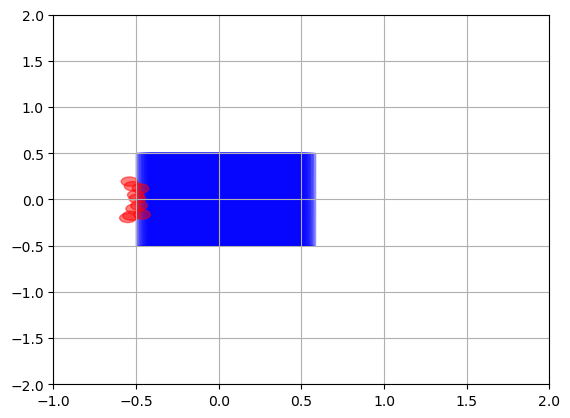

In [203]:
slider = Slider(size=np.array([1, 1]), mass=0.1, nu=1.0, state=np.array([0.0, 0.0, 0.0]))
pusher = Pusher(state=np.array([-0.55, -0.2]), size=0.05, mass=0.01, nu=0.3, control=np.array([0.0, 0.0]))
surface = Surface(nu=1.0)
goal_config_slider = np.array([0.6, 0.68, 0.45])

system = PlanarSystem(slider, pusher, surface)
simulator = Simulator(system, dt=0.001)
x = np.array(simulator.get_state())

theta = x[2]
iCs = np.array([[np.cos(theta), np.sin(theta)], [-np.sin(theta), np.cos(theta)]])
pxy = (iCs @ np.array([x[3], x[4]])) + np.array([slider.state[0], slider.state[1]])

print(pxy)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.set_xlim(-1, 2)
ax.set_ylim(-2, 2)
for i in range(10000):
    theta = x[2]
    iCs = np.array([[np.cos(theta), np.sin(theta)], [-np.sin(theta), np.cos(theta)]])
    
    u = np.array([0.01, -0.0])
    u = iCs.T @ u
    x_next = simulator.simulate(x, u)
    
    
    theta = x_next[2]
    pxy[1] = x_next[4]
    iCs = np.array([[np.cos(theta), np.sin(theta)], [-np.sin(theta), np.cos(theta)]])

    pxy_i = iCs.T @ (pxy +  iCs @ np.array([x_next[0], x_next[1]]))
    print(pxy_i)
    # need to update pusher position


    x_next[3] = pxy_i[0]
    x_next[4] = pxy_i[1]

    # print(x, x_next)
    x = x_next.copy()
    # if i > 1000:
    #     break

    simulator.set_state(x)
    # slider rectangle
    state = simulator.get_state()
    # print(state[3:])

    # print(state[2] * 180 / np.pi)
    
    if i % 1000 == 0:
        rect = plt.Rectangle((state[0] - slider.size[0]/2, state[1] - slider.size[1]/2), slider.size[0], slider.size[1], color='blue', alpha=0.3, angle=state[2] * 180 / np.pi, rotation_point='center')
        ax.add_patch(rect)
        # pusher circle
        circle = plt.Circle((state[3], state[4]), pusher.size, color='red', alpha=0.5)
        ax.add_patch(circle)

ax.grid()


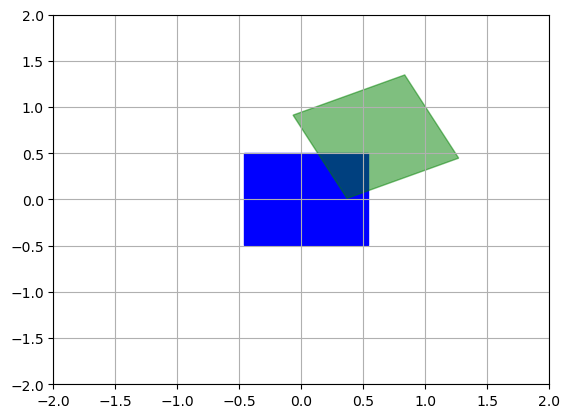

In [200]:
#  will put this in the simulation class later
fig = plt.figure()
ax = fig.add_subplot(111)
# slider rectangle
rect = plt.Rectangle((slider.state[0] - slider.size[0]/2, slider.state[1] - slider.size[1]/2), slider.size[0], slider.size[1], color='blue')
ax.add_patch(rect)
# pusher circle
circle = plt.Circle((pusher.state[0], pusher.state[1]), pusher.size, color='red')
ax.add_patch(circle)


# goal config slider rectangle
rect_goal = plt.Rectangle((goal_config_slider[0] - slider.size[0]/2, goal_config_slider[1] - slider.size[1]/2), slider.size[0], slider.size[1], color='green', angle=goal_config_slider[2] * 180 / np.pi, alpha=0.5, rotation_point='center')
ax.add_patch(rect_goal)

ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.grid()

In [204]:
slider = Slider(size=np.array([0.25, 0.25]), mass=0.1, nu=1.0, state=np.array([0.0, 0.0, 0.0]))
pusher = Pusher(state=np.array([-0.55, -0.2]), size=0.05, mass=5, nu=0.3, control=np.array([0.0, 0.0]))
surface = Surface(nu=1.0)
goal_config_slider = np.array([0.6, 0.68, 0.45])

system = PlanarSystem(slider, pusher, surface)
simulator = Simulator(system, dt=0.001)

In [ ]:
nu = system.pusher.nu
c = system.c
px_s 
gamma_top = (nu * c * c -  px_s * py_s + nu * px_s * px_s)/(c * c + py_s * py_s - nu * px_s * py_s)
gamma_bottom = (-nu * c * c -  px_s * py_s - nu * px_s * px_s)/(c * c + py_s * py_s + nu * px_s * py_s)